In [77]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DADES
# =========================
n_max = 6460  # rpm
n_nom = 5060  # rpm
P_nom = 20    # W

i = 66        # relació de transmissió

rG = 70e-3    # m, radi politja gran
rP = 40e-3    # m, radi politja petita

npuls = 4     # nombre de pulsos per volta de l'encoder
Xcomp = 1     # factor de compensació

x_f = 200e-3  # m, recorregut total del carro en direcció 
y_f = 150e-3  # m, recorregut total del carro en direcció y

eps_max = 1000  # m/s², acceleració màxima del carro
t_total = 1.2  # s, temps total del moviment (incloent acceleració i desacceleració)

In [78]:
# =========================
# CINEMÀTICA INVERSA
# =========================
i_t = i / rG

theta1_f = i_t * (x_f + y_f)
theta2_f = i_t * (-x_f)

### Sincronització d'acceleracions
El motor que requereix el desplaçament angular més gran (`theta1_f` o `theta2_f`) determina on s'aplica l'acceleració màxima `eps_max`.

- Si `abs(theta1_f) > abs(theta2_f)`: s'aplica `eps_max` a `ddtheta1` i es resol `t_b` a partir de `theta1_f`; `ddtheta2` s'ajusta perquè `theta2` completi el seu recorregut dins del temps restant.
- En cas contrari, s'aplica `eps_max` a `ddtheta2` i s'ajusta `ddtheta1`.

Aquesta estratègia sincronitza les fases d'acceleració i desacceleració dels dos motors dins de `t_total`, evitant que un eix finalitzi abans que l'altre i conservant un perfil simètric d'acceleració-velocitat-desacceleració.

In [79]:
# =========================
# DETERMINACIÓ MOVIMENT UNIFORMEMENT ACELERAT
# =========================
if abs(theta1_f) > abs(theta2_f):

    if  eps_max*t_total**2 >= 4*abs(theta1_f):

        ddtheta1 = eps_max * np.sign(theta1_f)

        t_b = t_total/2 - np.sqrt(ddtheta1**2 * t_total**2 - 4*abs(ddtheta1)*abs(theta1_f)) / (2*abs(ddtheta1))
        dtheta1 = t_b * ddtheta1

        ddtheta2 = theta2_f / (t_b*t_total - t_b**2)
        dtheta2 = t_b * ddtheta2

    else: 
        
        raise RuntimeError(
            f"Amb l'acceleració màxima `eps_max` de {eps_max:.1f} m/s² i el temps total `t_total` de {t_total:.2f} s, \n" 
            + f"no es pot assolir el desplaçament sol·licitat per `theta1_f` de {theta1_f:.3f} rad. \n"
            + f"El temps `t_total` per les dades d'entrada no pot inferior a {np.sqrt(4*abs(ddtheta1)*abs(theta1_f)/ddtheta1**2):.2f} s. \n"
            + "Augmenta `t_total`, augmenta `eps_max`, o verifica les dades d'entrada (p. ex. `theta_f`).")

 #           + f"El temps `t_total` per les dades d'entrada no pot inferior a {np.sqrt(4*abs(theta1_f/eps_max)):.2f} s. \n"

else:

    if  eps_max*t_total**2 >= 4*abs(theta2_f):

        ddtheta2 = eps_max * np.sign(theta2_f)

        t_b = t_total/2 - np.sqrt(ddtheta2**2 * t_total**2 - 4*abs(ddtheta2)*abs(theta2_f)) / (2*abs(ddtheta2))
        dtheta2 = t_b * ddtheta2

        ddtheta1 = theta1_f / (t_b*t_total - t_b**2)
        dtheta1 = t_b * ddtheta1

    else:
        
        raise RuntimeError(
            f"Amb l'acceleració màxima `eps_max` de {eps_max:.1f} m/s² i el temps total `t_total` de {t_total:.2f} s, \n" 
            + f"no es pot assolir el desplaçament sol·licitat per `theta1_f` de {theta2_f:.3f} rad. \n"
            + f"El temps `t_total` per les dades d'entrada no pot inferior a {np.sqrt(4*abs(ddtheta2)*abs(theta2_f)/ddtheta2**2):.2f} s. \n"
            + "Augmenta `t_total`, augmenta `eps_max`, o verifica les dades d'entrada (p. ex. `theta_f`).")

In [80]:
# =========================
# TEMPS
# =========================
t_abs1 = np.zeros(3)

t_abs1[0] = t_b
t_abs1[1] = t_abs1[0] + t_total - 2*t_b
t_abs1[2] = t_abs1[1] + t_b


# =========================
# POSICIONS FINALS TRAMS
# =========================
theta1_a = np.zeros(3)
theta2_a = np.zeros(3)

theta1_a[0] = 0.5 * ddtheta1 * t_abs1[0]**2
theta1_a[1] = theta1_a[0] + dtheta1*(t_abs1[1]-t_abs1[0])
theta1_a[2] = theta1_a[1] + dtheta1*(t_abs1[2]-t_abs1[1]) - 0.5*ddtheta1*(t_abs1[2]-t_abs1[1])**2

theta2_a[0] = 0.5 * ddtheta2 * t_abs1[0]**2
theta2_a[1] = theta2_a[0] + dtheta2*(t_abs1[1]-t_abs1[0])
theta2_a[2] = theta2_a[1] + dtheta2*(t_abs1[2]-t_abs1[1]) - 0.5*ddtheta2*(t_abs1[2]-t_abs1[1])**2

In [ ]:
# =========================
# DISPLAY (similar MATLAB disp)
# =========================
print("RESULTATS OBTINGUTS:")
print()

print("Motor 1")
print(f"t_b = {t_b:.3f} s, theta1_1 = {theta1_a[0]:.3f} rad, eps1 = {ddtheta1:.3f} rad/s2")
print(f"omega1 = {dtheta1:.3f} rad/s")
print(f"theta1 total = {abs(theta1_a[2]):.3f} rad")
print()

print("Motor 2")
print(f"t_b = {t_b:.3f} s, theta2_1 = {theta2_a[0]:.3f} rad, eps2 = {ddtheta2:.3f} rad/s2")
print(f"omega2 = {dtheta2:.3f} rad/s")
print(f"theta2 total = {abs(theta2_a[2]):.3f} rad")

RESULTATS DE L'EXERCICI

Motor 1
t_b = 0.427 s, theta1_1 = 91.077 rad, eps1 = 1000.000 rad/s2
omega1 = 426.795 rad/s
theta1 total = 330.000 rad

Motor 2
t_b = 0.427 s, theta2_1 = -52.044 rad, eps2 = -571.429 rad/s2
omega2 = -243.883 rad/s
theta2 total = 188.571 rad


In [ ]:
# =========================
# TRAJECTÒRIA DISCRETITZADA
# =========================
t_ = np.arange(0, t_total, 0.005)

theta1_ = np.zeros(len(t_))
dtheta1_ = np.zeros(len(t_))
ddtheta1_ = np.zeros(len(t_))

theta2_ = np.zeros(len(t_))
dtheta2_ = np.zeros(len(t_))
ddtheta2_ = np.zeros(len(t_))


# =========================
# BUCLE MOTOR 1 (FIDEL MATLAB)
# =========================
for ii in range(len(t_)):

    if t_[ii] <= t_abs1[0]:
        theta1_[ii] = 0.5*ddtheta1*t_[ii]**2
        dtheta1_[ii] = ddtheta1*t_[ii]
        ddtheta1_[ii] = ddtheta1

    elif t_[ii] <= t_abs1[1]:
        theta1_[ii] = theta1_a[0] + dtheta1*(t_[ii]-t_abs1[0])
        dtheta1_[ii] = dtheta1
        ddtheta1_[ii] = 0

    else:
        theta1_[ii] = theta1_a[1] + dtheta1*(t_[ii]-t_abs1[1]) - 0.5*ddtheta1*(t_[ii]-t_abs1[1])**2
        dtheta1_[ii] = dtheta1 - ddtheta1*(t_[ii]-t_abs1[1])
        ddtheta1_[ii] = -ddtheta1


# =========================
# BUCLE MOTOR 2 (FIDEL MATLAB)
# =========================
for ii in range(len(t_)):

    if t_[ii] <= t_abs1[0]:
        theta2_[ii] = 0.5*ddtheta2*t_[ii]**2
        dtheta2_[ii] = ddtheta2*t_[ii]
        ddtheta2_[ii] = ddtheta2

    elif t_[ii] <= t_abs1[1]:
        theta2_[ii] = theta2_a[0] + dtheta2*(t_[ii]-t_abs1[0])
        dtheta2_[ii] = dtheta2
        ddtheta2_[ii] = 0

    else:
        theta2_[ii] = theta2_a[1] + dtheta2*(t_[ii]-t_abs1[1]) - 0.5*ddtheta2*(t_[ii]-t_abs1[1])**2
        dtheta2_[ii] = dtheta2 - ddtheta2*(t_[ii]-t_abs1[1])
        ddtheta2_[ii] = -ddtheta2

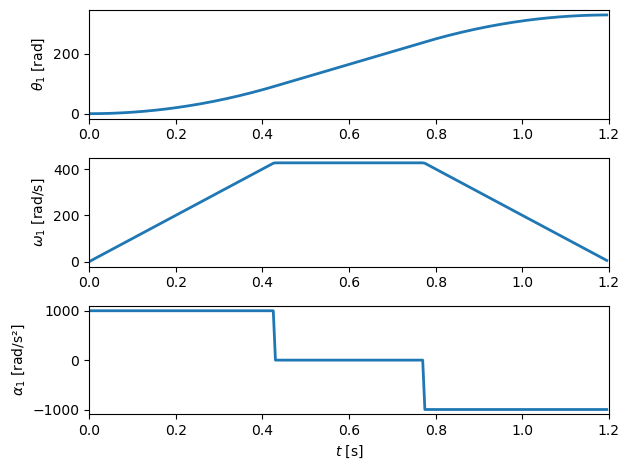

In [83]:
# =========================
# GRÀFIQUES MOTORS
# =========================
plt.figure()

plt.subplot(3,1,1)
plt.plot(t_, theta1_, linewidth=2)
plt.ylabel(r"$\theta_1$ [rad]")
plt.xlim(0, t_total)

plt.subplot(3,1,2)
plt.plot(t_, dtheta1_, linewidth=2)
plt.ylabel(r"$\omega_1$ [rad/s]")
plt.xlim(0, t_total)

plt.subplot(3,1,3)
plt.plot(t_, ddtheta1_, linewidth=2)
plt.ylabel(r"$\alpha_1$ [rad/s²]")
plt.xlabel(r"$t$ [s]")
plt.xlim(0, t_total)

plt.tight_layout()

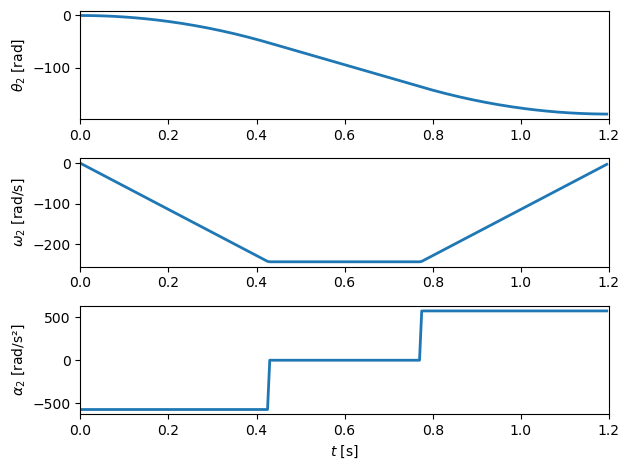

In [84]:
plt.figure()

plt.subplot(3,1,1)
plt.plot(t_, theta2_, linewidth=2)
plt.ylabel(r"$\theta_2$ [rad]")
plt.xlim(0, t_total)

plt.subplot(3,1,2)
plt.plot(t_, dtheta2_, linewidth=2)
plt.ylabel(r"$\omega_2$ [rad/s]")
plt.xlim(0, t_total)

plt.subplot(3,1,3)
plt.plot(t_, ddtheta2_, linewidth=2)
plt.ylabel(r"$\alpha_2$ [rad/s²]")
plt.xlabel(r"$t$ [s]")
plt.xlim(0, t_total)

plt.tight_layout()

(np.float64(-0.010000000000000002),
 np.float64(0.21000000000000002),
 np.float64(-0.0075),
 np.float64(0.1575))

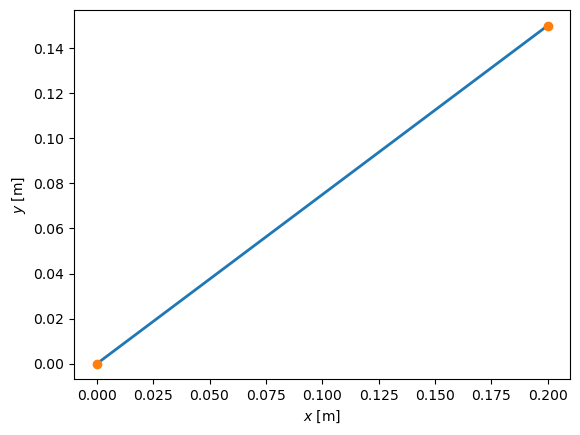

In [85]:
# =========================
# CINEMÀTICA DIRECTA XY
# =========================
i_t = i / rG

x = (0*theta1_ - theta2_) / i_t
y = (theta1_ + theta2_) / i_t

plt.figure()
plt.plot(x, y, linewidth=2)
plt.plot([0,x_f],[0,y_f],'o')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y$ [m]")
plt.axis("equal")

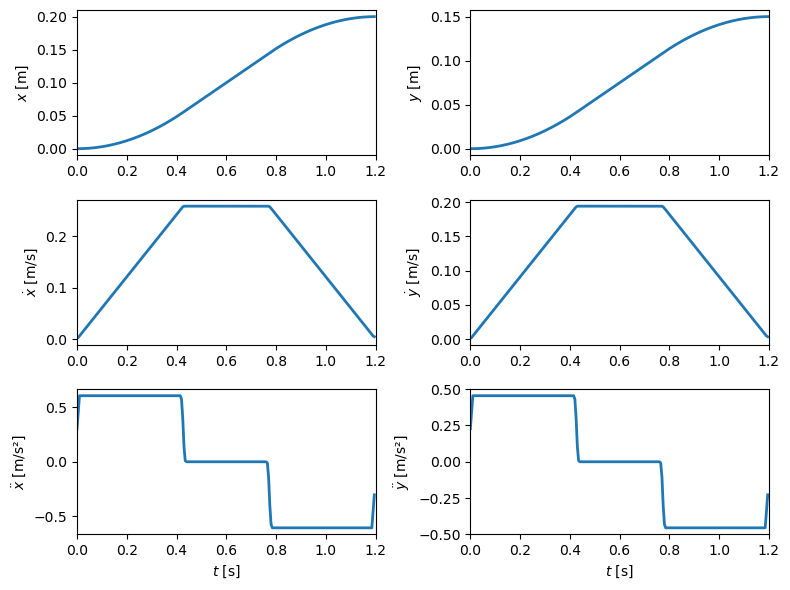

In [91]:
# =========================
# XY vs temps (3 files x 2 columnes)
# =========================
plt.figure(figsize=(8,6))

plt.subplot(3,2,1)
plt.plot(t_, x, linewidth=2)
plt.ylabel(r"$x$ [m]")
plt.xlim(0, t_total)

plt.subplot(3,2,2)
plt.plot(t_, y, linewidth=2)
plt.ylabel(r"$y$ [m]")
plt.xlim(0, t_total)

plt.subplot(3,2,3)
plt.plot(t_, np.gradient(x, t_), linewidth=2)
plt.ylabel(r"$\dot{x}$ [m/s]")
plt.xlim(0, t_total)

plt.subplot(3,2,4)
plt.plot(t_, np.gradient(y, t_), linewidth=2)
plt.ylabel(r"$\dot{y}$ [m/s]")
plt.xlim(0, t_total)

plt.subplot(3,2,5)
plt.plot(t_, np.gradient(np.gradient(x, t_), t_), linewidth=2)
plt.ylabel(r"$\ddot{x}$ [m/s²]")
plt.xlabel(r"$t$ [s]")
plt.xlim(0, t_total)

plt.subplot(3,2,6)
plt.plot(t_, np.gradient(np.gradient(y, t_), t_), linewidth=2)
plt.ylabel(r"$\ddot{y}$ [m/s²]")
plt.xlabel(r"$t$ [s]")
plt.xlim(0, t_total)

plt.tight_layout()

plt.show()